## Загрузка, трансформация и обработка первичных данных

In [64]:
# импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from pylab import rcParams
from IPython.display import display
import math
pd.set_option('display.max_columns', 130)

import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", category=InterpolationWarning)
# pd.set_option('future.no_silent_downcasting', False)


#### Data preparation

In [65]:
# загрузка входных данных и сохранение в датасет
df = pd.read_excel("../input data/Данные-рус Бюро 2025 год.xlsx")
df.head(5)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89,Unnamed: 90,Unnamed: 91,Unnamed: 92,Unnamed: 93,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103,Unnamed: 104,Unnamed: 105,Unnamed: 106,Unnamed: 107,Unnamed: 108,Unnamed: 109,Unnamed: 110,Unnamed: 111,Unnamed: 112,Unnamed: 113,Unnamed: 114,Unnamed: 115,Unnamed: 116,Unnamed: 117,Unnamed: 118,Unnamed: 119,Unnamed: 120,Unnamed: 121,Unnamed: 122,Unnamed: 123,Unnamed: 124,Unnamed: 125,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Показатель,Категория хозяйства,Регион,2015-01-01 00:00:00,2015-02-01 00:00:00,2015-03-01 00:00:00,2015-04-01 00:00:00,2015-05-01 00:00:00,2015-06-01 00:00:00,2015-07-01 00:00:00,2015-08-01 00:00:00,2015-09-01 00:00:00,2015-10-01 00:00:00,2015-11-01 00:00:00,2015-12-01 00:00:00,2016-01-01 00:00:00,2016-02-01 00:00:00,2016-03-01 00:00:00,2016-04-01 00:00:00,2016-05-01 00:00:00,2016-06-01 00:00:00,2016-07-01 00:00:00,2016-08-01 00:00:00,2016-09-01 00:00:00,2016-10-01 00:00:00,2016-11-01 00:00:00,2016-12-01 00:00:00,2017-01-01 00:00:00,2017-02-01 00:00:00,2017-03-01 00:00:00,2017-04-01 00:00:00,2017-05-01 00:00:00,2017-06-01 00:00:00,2017-07-01 00:00:00,2017-08-01 00:00:00,2017-09-01 00:00:00,2017-10-01 00:00:00,2017-11-01 00:00:00,2017-12-01 00:00:00,2018-01-01 00:00:00,2018-02-01 00:00:00,2018-03-01 00:00:00,2018-04-01 00:00:00,2018-05-01 00:00:00,2018-06-01 00:00:00,2018-07-01 00:00:00,2018-08-01 00:00:00,2018-09-01 00:00:00,2018-10-01 00:00:00,2018-11-01 00:00:00,2018-12-01 00:00:00,2019-01-01 00:00:00,2019-02-01 00:00:00,2019-03-01 00:00:00,2019-04-01 00:00:00,2019-05-01 00:00:00,2019-06-01 00:00:00,2019-07-01 00:00:00,2019-08-01 00:00:00,2019-09-01 00:00:00,2019-10-01 00:00:00,2019-11-01 00:00:00,2019-12-01 00:00:00,2020-01-01 00:00:00,2020-02-01 00:00:00,2020-03-01 00:00:00,2020-04-01 00:00:00,2020-05-01 00:00:00,2020-06-01 00:00:00,2020-07-01 00:00:00,2020-08-01 00:00:00,2020-09-01 00:00:00,2020-10-01 00:00:00,2020-11-01 00:00:00,2020-12-01 00:00:00,2021-01-01 00:00:00,2021-02-01 00:00:00,2021-03-01 00:00:00,2021-04-01 00:00:00,2021-05-01 00:00:00,2021-06-01 00:00:00,2021-07-01 00:00:00,2021-08-01 00:00:00,2021-09-01 00:00:00,2021-10-01 00:00:00,2021-11-01 00:00:00,2021-12-01 00:00:00,2022-01-01 00:00:00,2022-02-01 00:00:00,2022-03-01 00:00:00,2022-04-01 00:00:00,2022-05-01 00:00:00,2022-06-01 00:00:00,2022-07-01 00:00:00,2022-08-01 00:00:00,2022-09-01 00:00:

In [66]:
# удаление первого (пустого) ряда
df = df.drop(index=df.index[:1]).reset_index(drop=True)
df.head(5)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89,Unnamed: 90,Unnamed: 91,Unnamed: 92,Unnamed: 93,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103,Unnamed: 104,Unnamed: 105,Unnamed: 106,Unnamed: 107,Unnamed: 108,Unnamed: 109,Unnamed: 110,Unnamed: 111,Unnamed: 112,Unnamed: 113,Unnamed: 114,Unnamed: 115,Unnamed: 116,Unnamed: 117,Unnamed: 118,Unnamed: 119,Unnamed: 120,Unnamed: 121,Unnamed: 122,Unnamed: 123,Unnamed: 124,Unnamed: 125,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129
0,Показатель,Категория хозяйства,Регион,2015-01-01 00:00:00,2015-02-01 00:00:00,2015-03-01 00:00:00,2015-04-01 00:00:00,2015-05-01 00:00:00,2015-06-01 00:00:00,2015-07-01 00:00:00,2015-08-01 00:00:00,2015-09-01 00:00:00,2015-10-01 00:00:00,2015-11-01 00:00:00,2015-12-01 00:00:00,2016-01-01 00:00:00,2016-02-01 00:00:00,2016-03-01 00:00:00,2016-04-01 00:00:00,2016-05-01 00:00:00,2016-06-01 00:00:00,2016-07-01 00:00:00,2016-08-01 00:00:00,2016-09-01 00:00:00,2016-10-01 00:00:00,2016-11-01 00:00:00,2016-12-01 00:00:00,2017-01-01 00:00:00,2017-02-01 00:00:00,2017-03-01 00:00:00,2017-04-01 00:00:00,2017-05-01 00:00:00,2017-06-01 00:00:00,2017-07-01 00:00:00,2017-08-01 00:00:00,2017-09-01 00:00:00,2017-10-01 00:00:00,2017-11-01 00:00:00,2017-12-01 00:00:00,2018-01-01 00:00:00,2018-02-01 00:00:00,2018-03-01 00:00:00,2018-04-01 00:00:00,2018-05-01 00:00:00,2018-06-01 00:00:00,2018-07-01 00:00:00,2018-08-01 00:00:00,2018-09-01 00:00:00,2018-10-01 00:00:00,2018-11-01 00:00:00,2018-12-01 00:00:00,2019-01-01 00:00:00,2019-02-01 00:00:00,2019-03-01 00:00:00,2019-04-01 00:00:00,2019-05-01 00:00:00,2019-06-01 00:00:00,2019-07-01 00:00:00,2019-08-01 00:00:00,2019-09-01 00:00:00,2019-10-01 00:00:00,2019-11-01 00:00:00,2019-12-01 00:00:00,2020-01-01 00:00:00,2020-02-01 00:00:00,2020-03-01 00:00:00,2020-04-01 00:00:00,2020-05-01 00:00:00,2020-06-01 00:00:00,2020-07-01 00:00:00,2020-08-01 00:00:00,2020-09-01 00:00:00,2020-10-01 00:00:00,2020-11-01 00:00:00,2020-12-01 00:00:00,2021-01-01 00:00:00,2021-02-01 00:00:00,2021-03-01 00:00:00,2021-04-01 00:00:00,2021-05-01 00:00:00,2021-06-01 00:00:00,2021-07-01 00:00:00,2021-08-01 00:00:00,2021-09-01 00:00:00,2021-10-01 00:00:00,2021-11-01 00:00:00,2021-12-01 00:00:00,2022-01-01 00:00:00,2022-02-01 00:00:00,2022-03-01 00:00:00,2022-04-01 00:00:00,2022-05-01 00:00:00,2022-06-01 00:00:00,2022-07-01 00:00:00,2022-08-01 00:00:00,2022-09-01 00:00:00,2022-10-01 00:00:00,2022-11-01 00:00:00,2022-12-01 00:00:00,2023-01-01 00:00:00,2023-02-01 00:00:00,2023-03-01 00:00:00,2023-04-01 00:00:00,2023-05-01 00:00:00,2023-06-01 00:00:00,2023-07-01 00:00:00,2023-08-01 00:00:00,2023-09-01 00:00:00,2023-10-01 00:00:00,2023-11-01 00:00:00,2023-12-01 00:00:00,2024-01-01 00:00:00,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00

In [67]:
# первый ряд как заголовки столбцов
df.columns = df.iloc[0] 
df = df[1:].reset_index(drop=True)
df.head(5)

,Показатель,Категория хозяйства,Регион,2015-01-01 00:00:00,2015-02-01 00:00:00,2015-03-01 00:00:00,2015-04-01 00:00:00,2015-05-01 00:00:00,2015-06-01 00:00:00,2015-07-01 00:00:00,2015-08-01 00:00:00,2015-09-01 00:00:00,2015-10-01 00:00:00,2015-11-01 00:00:00,2015-12-01 00:00:00,2016-01-01 00:00:00,2016-02-01 00:00:00,2016-03-01 00:00:00,2016-04-01 00:00:00,2016-05-01 00:00:00,2016-06-01 00:00:00,2016-07-01 00:00:00,2016-08-01 00:00:00,2016-09-01 00:00:00,2016-10-01 00:00:00,2016-11-01 00:00:00,2016-12-01 00:00:00,2017-01-01 00:00:00,2017-02-01 00:00:00,2017-03-01 00:00:00,2017-04-01 00:00:00,2017-05-01 00:00:00,2017-06-01 00:00:00,2017-07-01 00:00:00,2017-08-01 00:00:00,2017-09-01 00:00:00,2017-10-01 00:00:00,2017-11-01 00:00:00,2017-12-01 00:00:00,2018-01-01 00:00:00,2018-02-01 00:00:00,2018-03-01 00:00:00,2018-04-01 00:00:00,2018-05-01 00:00:00,2018-06-01 00:00:00,2018-07-01 00:00:00,2018-08-01 00:00:00,2018-09-01 00:00:00,2018-10-01 00:00:00,2018-11-01 00:00:00,2018-12-01 00:00:00,2019-01-01 00:00:00,2019-02-01 00:00:00,2019-03-01 00:00:00,2019-04-01 00:00:00,2019-05-01 00:00:00,2019-06-01 00:00:00,2019-07-01 00:00:00,2019-08-01 00:00:00,2019-09-01 00:00:00,2019-10-01 00:00:00,2019-11-01 00:00:00,2019-12-01 00:00:00,2020-01-01 00:00:00,2020-02-01 00:00:00,2020-03-01 00:00:00,2020-04-01 00:00:00,2020-05-01 00:00:00,2020-06-01 00:00:00,2020-07-01 00:00:00,2020-08-01 00:00:00,2020-09-01 00:00:00,2020-10-01 00:00:00,2020-11-01 00:00:00,2020-12-01 00:00:00,2021-01-01 00:00:00,2021-02-01 00:00:00,2021-03-01 00:00:00,2021-04-01 00:00:00,2021-05-01 00:00:00,2021-06-01 00:00:00,2021-07-01 00:00:00,2021-08-01 00:00:00,2021-09-01 00:00:00,2021-10-01 00:00:00,2021-11-01 00:00:00,2021-12-01 00:00:00,2022-01-01 00:00:00,2022-02-01 00:00:00,2022-03-01 00:00:00,2022-04-01 00:00:00,2022-05-01 00:00:00,2022-06-01 00:00:00,2022-07-01 00:00:00,2022-08-01 00:00:00,2022-09-01 00:00:00,2022-10-01 00:00:00,2022-11-01 00:00:00,2022-12-01 00:00:00,2023-01-01 00:00:00,2023-02-01 00:00:00,2023-03-01 00:00:00,2023-04-01 00:00:00,2023-05-01 00:00:00,2023-06-01 00:00:00,2023-07-01 00:00:00,2023-08-01 00:00:00,2023-09-01 00:00:00,2023-10-01 00:00:00,2023-11-01 00:00:00,2023-12-01 00:00:00,2024-01-01 00:00:00,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,2024-12-01 00:00:00,2025-01-01 00:00:00,2025-02-01 00:00:00,2025-03-01 00:00:00,2025-04-01 00:00:00,2025-05-01 00:00:00,2025-06-01 00:00:00,2025-07-01 00:00:00
0,КРС,Сельхозпредприятия,РЕСПУБЛИКА КАЗАХСТАН,3400.96,3685.9,4154.43,5203.94,5084.05,6718.83,4235.03,4014.95,4907.52,4274.75,3858.39,6477.35,3884.84,4146.9,4282.08,5408.9,4390.56,8005.48,5105.84,4700.12,5548.88,3958.09,6264.34,9196.32,3739.75,4951.17,6316.68,5751.36,5747.16,10114.01,5944.43,6768.61,5781.59,5885.5,7429.34,9411.91,5555.9,4586.48,7970.28,8130.34,8048.48,14491.87,7543.26,7396.97,9668.6,6730.17,7987.91,11121.61,5666.49,5917.68,8899.55,7784.95,9167.13,16299.73,7164.2,7341.17,10162.65,13532.56,11737.17,14948.7,7041.38,4341.74,10336.12,7419.05,10452.61,16413.66,7973.85,8901.52,10934.83,13130.82,12848.98,18882.81,8135.62,6432.18,9650.38,10482.45,11405.76,16121.49,9114.93,14885.29,13567.02,13473.97,12558.44,20382.82,6709.4,8554.71,12487.58,9184.25,7094.7,16471.11,6373.02,10145.08,8831.12,11123,8927.05,11379.06,7452.75,6836.85,8719.53,9925.26,7684.37,12218.39,6460.2,11289.58,15156.55,9790.74,9021.76,13193.63,6799.94,12303.66,9703.45,11165.56,8179.14,24407.52,9835.22,11955.41,16955.56,10638.42,9612.92,21521.5,6844.96,6687.71,8238.73,7324.04,7044.61,14116.34,10179.94
1,КРС,Сельхозпредприятия,АКМОЛИНСКАЯ ОБЛАСТЬ,514.75,497.95,863.93,667.81,633.39,600.86,875.47,942.18,856.9,981.04,873.89,1390.18,736.62,845.64,774.36,618.97,701.72,796.48,914.5,736.52,897.89,912.46,867.99,1102.48,660.12,731.14,835,860.71,883.43,963.32,745.3,844.01,678,1025.12,1312.34,919.29,670.25,942.66,847.27,907.92,1002.24,911.6

In [68]:
# трансформация столбцов с датами
df.columns = list(df.columns[:3]) + list(pd.to_datetime(df.columns[-127:]))
df = df.rename(columns={col: col.strftime("%Y-%m") for col in df.columns[-127:]}) # замена "2015-01-01 00:00:00" на "2015-01" 
df.head(5)

,Показатель,Категория хозяйства,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
0,КРС,Сельхозпредприятия,РЕСПУБЛИКА КАЗАХСТАН,3400.96,3685.9,4154.43,5203.94,5084.05,6718.83,4235.03,4014.95,4907.52,4274.75,3858.39,6477.35,3884.84,4146.9,4282.08,5408.9,4390.56,8005.48,5105.84,4700.12,5548.88,3958.09,6264.34,9196.32,3739.75,4951.17,6316.68,5751.36,5747.16,10114.01,5944.43,6768.61,5781.59,5885.5,7429.34,9411.91,5555.9,4586.48,7970.28,8130.34,8048.48,14491.87,7543.26,7396.97,9668.6,6730.17,7987.91,11121.61,5666.49,5917.68,8899.55,7784.95,9167.13,16299.73,7164.2,7341.17,10162.65,13532.56,11737.17,14948.7,7041.38,4341.74,10336.12,7419.05,10452.61,16413.66,7973.85,8901.52,10934.83,13130.82,12848.98,18882.81,8135.62,6432.18,9650.38,10482.45,11405.76,16121.49,9114.93,14885.29,13567.02,13473.97,12558.44,20382.82,6709.4,8554.71,12487.58,9184.25,7094.7,16471.11,6373.02,10145.08,8831.12,11123,8927.05,11379.06,7452.75,6836.85,8719.53,9925.26,7684.37,12218.39,6460.2,11289.58,15156.55,9790.74,9021.76,13193.63,6799.94,12303.66,9703.45,11165.56,8179.14,24407.52,9835.22,11955.41,16955.56,10638.42,9612.92,21521.5,6844.96,6687.71,8238.73,7324.04,7044.61,14116.34,10179.94
1,КРС,Сельхозпредприятия,АКМОЛИНСКАЯ ОБЛАСТЬ,514.75,497.95,863.93,667.81,633.39,600.86,875.47,942.18,856.9,981.04,873.89,1390.18,736.62,845.64,774.36,618.97,701.72,796.48,914.5,736.52,897.89,912.46,867.99,1102.48,660.12,731.14,835,860.71,883.43,963.32,745.3,844.01,678,1025.12,1312.34,919.29,670.25,942.66,847.27,907.92,1002.24,911.62,873.09,1070.9,938.24,832.71,780.14,792.74,993.76,1044.12,1250.31,892.18,1441.82,1249.59,822.67,1007.64,1333,1160.5,1088.61,1164.95,782.49,829.6,1780.71,1077.39,1145.56,1100.69,898.78,829.67,930.63,1135.02,1025.99,1133.29,1141.02,957.47,1261.8,979.49,1029.19,864.06,1056.22,1019.37,1028.55,1254.05,1025.9,1062.94,537.96,1089,1631.34,1183.73,1118.31,1064.21,1240.11,1000.26,1269.72,1136.14,1230.95,1026.95,1294.11,936.76,1229.11,1048.76,1040.48,1181.82,869.84,993.64,938.85,1102.67,1001.63,1079.39,972.07,938.35,978.41,1071.35,1067.76,1119.61,898.07,1382,1133.36,1073.27,1118.19,1332.88,837.79,1082.43,1426.73,1238.21,1262.37,1269.83,1261.41
2,КРС,Сельхозпредприятия,АКТЮБИНСКАЯ ОБЛАСТЬ,554.41,504.35,493.56,445.51,585.79,316.47,469.49,303.09,685.51,600.85,603.26,700.48,477.84,221.08,265.59,328.03,384.03,555.07,615.9,619.33,770.79,302.27,1076.31,862.54,473.66,475.3,814.18,638.87,642.96,834.97,902.65,701.17,756.63,726.68,654.31,801.49,703.32,514.47,952.16,1018.39,968.68,845.85,758.18,931.47,1070.07,1278.41,1627.73,1714.64,704.51,899.66,1554.1,1351.44,1050.71,1485.45,814.13,1169.81,2388.34,1595.4,3809.76,3510.19,954.53,481.35,1111.55,1033.96,1939.87,2152.47,1578.87,1426.39,2620.87,2434.4,3247.3,3281.67,580.89,823.34,1221.21,1626.06,1920.41,2637.56,1620.81,2134.96,3425.67,3449.02,3751.75,3827.39,826.17,1132.81,1544.91,1885.46,698.01,4712.69,508.07,592.19,902.26,1479.36,1219.25,658.78,589.8,1275.24,1508.27,1380.18,842.24,3478.29,774.46,764.8,3003.94,1876.68,1547.77,607.03,609.08,873.05,1520.51,1747.09,915.8,1851.

In [69]:
# проверка значений по столбцам
print(df["Показатель"].unique())
print(df["Категория хозяйства"].unique())
print(df["Регион"].unique())

['КРС' 'Свиньи' 'Лошади' 'Верблюды' 'Птица' 'Молоко' 'Яйца' 'Овцы и козы']
['Сельхозпредприятия' 'Крестьянские или фермерские хозяйства'
 'Хозяйства населения']
['РЕСПУБЛИКА КАЗАХСТАН' '    АКМОЛИНСКАЯ ОБЛАСТЬ'
 '    АКТЮБИНСКАЯ ОБЛАСТЬ' '    АЛМАТИНСКАЯ ОБЛАСТЬ'
 '    АТЫРАУСКАЯ ОБЛАСТЬ' '    ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ'
 '    ЖАМБЫЛСКАЯ ОБЛАСТЬ' '    КАРАГАНДИНСКАЯ ОБЛАСТЬ'
 '    КОСТАНАЙСКАЯ ОБЛАСТЬ' '    КЫЗЫЛОРДИНСКАЯ ОБЛАСТЬ'
 '    МАНГИСТАУСКАЯ ОБЛАСТЬ' '    ЮЖНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ'
 '    ПАВЛОДАРСКАЯ ОБЛАСТЬ' '    СЕВЕРО-КАЗАХСТАНСКАЯ ОБЛАСТЬ'
 '    ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ' '    ГАСТАНА' '    ГАЛМАТЫ'
 '    ГШЫМКЕНТ' '    ТУРКЕСТАНСКАЯ ОБЛАСТЬ' '    ОБЛАСТЬ ЖЕТІСУ'
 '    ОБЛАСТЬ ҰЛЫТАУ' '    ОБЛАСТЬ АБАЙ']


In [70]:
# очистка значений по столбцу "Регион"
df["Регион"] = df["Регион"].str.strip() # удаление лишних пробелов 
df = df[df["Регион"] != "ЮЖНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ"] # удаление ЮКО
df = df[df["Регион"] != "РЕСПУБЛИКА КАЗАХСТАН"] # удаление ЮКО

df["Регион"].unique()

array(['АКМОЛИНСКАЯ ОБЛАСТЬ', 'АКТЮБИНСКАЯ ОБЛАСТЬ',
       'АЛМАТИНСКАЯ ОБЛАСТЬ', 'АТЫРАУСКАЯ ОБЛАСТЬ',
       'ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ', 'ЖАМБЫЛСКАЯ ОБЛАСТЬ',
       'КАРАГАНДИНСКАЯ ОБЛАСТЬ', 'КОСТАНАЙСКАЯ ОБЛАСТЬ',
       'КЫЗЫЛОРДИНСКАЯ ОБЛАСТЬ', 'МАНГИСТАУСКАЯ ОБЛАСТЬ',
       'ПАВЛОДАРСКАЯ ОБЛАСТЬ', 'СЕВЕРО-КАЗАХСТАНСКАЯ ОБЛАСТЬ',
       'ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ', 'ГАСТАНА', 'ГАЛМАТЫ', 'ГШЫМКЕНТ',
       'ТУРКЕСТАНСКАЯ ОБЛАСТЬ', 'ОБЛАСТЬ ЖЕТІСУ', 'ОБЛАСТЬ ҰЛЫТАУ',
       'ОБЛАСТЬ АБАЙ'], dtype=object)

In [56]:
df.tail(5)

,Показатель,Категория хозяйства,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
523,Овцы и козы,Хозяйства населения,ГШЫМКЕНТ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113.19,109.5,107.5,109.61,110.1,123.3,329,91.1,80.1,84.1,84.5,90.9,82.3,88.8,74,75.1,84.4,78.3,339.5,87.8,86.2,84.1,84.5,90.9,82.3,88.8,74,75.1,84.4,78.3,75.1,88.3,70.4,56.5,45.6,50.6,46.2,42.7,40.7,47.8,50.6,47.9,359.5,89.1,70.7,56.7,44.7,46.4,46.3,42,39.7,46.3,48.4,46.2,174.8,88.3,68.3,54.7,43.5,46.4,44.2,42.1,39.7,46.3,48.4,46.2,174.8,88.2,68.3,54.6,43.7,46.4,44.2,42,39.7,50.7,49,46.2,174.8,88.2,68.3,54.6,44.7,45.5,49.4,43.1
524,Овцы и козы,Хозяйства населения,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5199.07,4570.03,4854.96,5303.53,6090.55,5718.8,7403.46,6204.08,5733.43,5593.5,4994.46,4774.99,4728.19,4398.32,4936.91,5536.35,6242.61,5720.59,7478.67,6347.3,5715.5,5566.5,4964.1,4664.4,4818.6,4424.8,4843.6,5517.7,6199,5702.3,7601.6,6457,5803.5,5615.4,4981.1,4699.8,4817.4,4410.3,4799.2,5529.5,6247.3,5730.3,7829.9,6525.4,5870.5,5506,4898.4,4647.5,4709.3,4163.5,4586.1,5378.3,5998.9,5568.9,7787,6503.13,5814.36,5337.86,4678.92,4479.58,4572.33,3427.03,3947.03,5202.49,5752.46,5381.07,7348.42,4421.7,4445.2,3904.3,3414.9,3224.1,3182.1,1823.1,2272.9,3341.6,3790.5,4074.5,5796.7,4127.3,3912.6,3574.8,3220.7,2902.9,2934.8,1507.2
525,Овцы и козы,Хозяйства населения,ОБЛАСТЬ ЖЕТІСУ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3358.6,591.2,1237.6,2046.3,2415.8,2173.3,3951.1,459.09,472.31,2054.34,645.26,493.88,2984.48,527.36,1130.62,2069.94,2129.18,2175.72,3669.04,464.5,477.4,2077.3,656.4,500.8,3064.5,547.4,1156.3,2134.4,2237.4,2093.4,3738.4,472.3,490.7,2305.7,655.6,482.7,3150.5,571.2
526,Овцы и козы,Хозяйства населения,ОБЛАСТЬ ҰЛЫТАУ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,281.8,87.6,137,455,182.9,184.8,634.3,188.43,84.88,239.96,64.64,489.3,422.24,85.07,207.07,657.05,218.33,214.88,217.8,162.1,220.6,198.3,65.4,490.1,376.7,86.4,213.8,455.5,216.7,169.2,216.1,161.3,218.9,197,64.9,486.7,374.6,86.2
527,Овцы и козы,Хозяйства населения,ОБЛАСТЬ АБАЙ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [57]:
df[(df['Показатель'] == 'Яйца') & (df['Категория хозяйства'] == 'Хозяйства населения')]

,Показатель,Категория хозяйства,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
440,Яйца,Хозяйства населения,РЕСПУБЛИКА КАЗАХСТАН,49281.9,47440.1,95545.4,109694.4,163593.5,159493.9,159493.9,137708.4,108951.8,77408.2,73153.3,77620.7,48947.4,48947.4,96247.7,112687.2,126377.5,167444.1,157550.1,138750,114555.5,80401,74987.3,82125.3,47428.7,46607.3,93323.3,107149,123381.8,165537.9,154557.8,137308.5,113520.8,76572.9,73710.9,79153.4,47627.9,46403.1,93239,105326.8,121734.8,162972.9,153824.1,137929.8,113888.5,74482.3,74448.7,77721.9,46367.7,46216.9,97368,107684.2,123599.4,164965.3,159292,142280.3,116055.7,75997.1,75050,79795.7,47525.3,47164.4,97468.3,110582.7,125410.9,164521,162069.2,144659.4,116480,75486.7,75573.9,80340.5,47995.7,47466.9,97253.3,111168.7,126511.7,166349.5,161967.7,146201,116856.3,74918,75358.1,80100.4,47571.4,47502.9,95028.1,109266.1,125393.1,165200.9,163462.2,143582,117528,73936.5,74845.5,74259.1,30221.3,31827.8,51954.2,61517.2,74197.4,95406.2,90468,79460.3,68295.8,48159.8,41282.8,42361,29715.8,29931,50383.9,59792.2,72390.7,93601.4,89681.5,77493.7,66982,46729.6,39443.6,41310.7,28461.9,29293.9,47764.8,57439,69080,88470.1,89707.3
441,Яйца,Хозяйства населения,АКМОЛИНСКАЯ ОБЛАСТЬ,2497.7,2864.7,4328.7,7095.8,12913.8,12846.4,12846.4,9810.5,7746.8,5612.8,3805.2,3841.4,2453,2453,4412.6,7281.9,12134.1,13315.7,13342.8,14565.5,12452,10039.8,6030.3,8187.2,2453,2965.5,4503.2,7378.1,12274.6,13553.3,13618.5,10531.5,8235.3,6314.2,4056.1,5534.6,2444,2907.2,4543.5,7370.5,12164.3,13511.9,13585.3,10585.3,8033.2,6471.8,4102.6,4356.1,2398.2,2860.5,4541.6,7419.4,12211.5,13645.9,13638.4,10520.4,7803.6,6459.5,4108.4,4359.7,2347.2,2772.6,4600.8,7486.6,12275.5,13780.1,13676.8,10641.9,7849.5,6355.8,4085.7,4355.2,2324.6,2710.3,4532.8,7432.7,12310.3,13827.8,13697.2,10634,7792.8,6360,4014.7,4316.5,2324.5,2720.7,4538.5,7471.1,12376.8,13948.4,13691.2,10602.4,7720.7,6346.1,4005.7,4226.9,1615.1,2023.9,3507.6,5788.6,9133.9,10368.8,10511,7977.3,6012,4693.4,3028.6,2988.4,1755.6,2187.3,3720.8,6071.6,9586.9,10791.9,10846.7,8362,6405.1,4871.5,3139,3125.4,1746.6,2185.7,3784.5,5946.8,9482,10852.7,10656.9
442,Яйца,Хозяйства населения,АКТЮБИНСКАЯ ОБЛАСТЬ,5724.3,4323.6,5169.5,4926.3,7965.5,7417.8,7417.8,6387.5,8225.3,6342.2,5104.1,4289.6,5822,5822,5313.7,4997.6,5960,8183.7,7588.1,6391.1,8858.5,6459.7,5104.4,3639.6,5867.4,4483.1,5380.8,5038.3,6051.7,8308,7729.7,6487.9,8838.9,6601.2,5171.8,3765.4,5941.9,4551.7,5500.5,5128.8,6213.4,8463.8,7966.9,6636.2,8893.8,6686.5,5262.3,3818.2,6070.3,4629.7,5593.8,5217.7,6370.1,8643.5,8107.3,6708,9016.1,6811.5,5350.2,3813.7,6148,4689.2,5664.1,5338.6,6467,8766.7,8230.8,6820,9106.6,6922.2,5445.7,3885.5,6205,4751.4,5766.7,5419,6563.8,8928.9,8371.4,6910.8,9197.3,6998,5544.4,3906.6,6145.8,4533.5,5612.8,5007.1,5528.6,9035,9370.7,6796.8,9107.5,6681,5562.2,3662.3,4950.9,3543.4,4062.2,3740.5,4031.6,5918,6022.9,4303.4,6403.2,4913.2,4504.7,2838.3,4809.2,3334.5,3887.4,3465.5,3816.4,5831.6,5888.3,4179.1,6410.8,4873.8,4332.9,2839.1,4708.1,3368.2,3936,3610.4,3984.4,5205.4,5685.6
443,Яйца

In [58]:
# df.groupby("Показатель").apply(lambda g: g.isna().sum())


In [71]:
for col in df.columns[3:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# проверка: есть ли ещё нечисловые
non_numeric = df[df.columns[3:]].select_dtypes(exclude='number').columns
print("Non-numeric columns:", list(non_numeric))


Non-numeric columns: []


In [72]:
# суммирование значений по категориям хозяйств (СХП, КФХ, ХН)
totals = (
    df.groupby(["Показатель", "Регион"])[df.columns[3:]]
      .sum(min_count=1)        # если все NA -> NaN, иначе обычная сумма
      .reset_index()
)

totals


,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
0,Верблюды,АКМОЛИНСКАЯ ОБЛАСТЬ,NaN,NaN,0.40,NaN,NaN,NaN,0.09,1.00,NaN,NaN,0.20,NaN,NaN,0.18,0.28,NaN,NaN,0.40,NaN,NaN,0.65,NaN,0.31,1.00,NaN,NaN,NaN,NaN,NaN,2.01,NaN,1.20,NaN,NaN,2.18,0.39,NaN,NaN,1.04,NaN,0.14,2.08,NaN,NaN,NaN,NaN,NaN,0.30,NaN,NaN,NaN,0.66,NaN,0.33,NaN,0.9,NaN,NaN,NaN,10.08,NaN,NaN,NaN,NaN,NaN,0.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Верблюды,АКТЮБИНСКАЯ ОБЛАСТЬ,101.98,67.47,374.84,115.59,218.72,14.15,19.77,3.00,39.16,46.16,238.56,463.35,109.04,72.94,384.96,114.35,221.89,10.93,18.79,3.50,38.53,46.64,216.08,472.07,110.32,68.17,380.15,127.12,217.61,14.98,21.26,7.14,44.63,51.78,239.43,513.33,115.70,69.40,371.53,130.17,218.41,14.59,21.76,7.19,45.97,55.48,252.68,527.66,117.94,70.37,385.75,117.80,218.45,15.54,21.78,7.2,47.06,58.02,257.54,543.35,119.80,71.3,396.90,121.8,228.10,15.90,21.9,7.2,63.00,59.90,260.20,552.10,121.60,71.8,398.40,128.50,228.80,13.10,22.50,7.20,63.90,61.90,150.70,554.90,121.30,73.3,404.20,128.70,234.90,13.60,23.60,6.3,49.80,62.4,153.70,552.8,118.07,69.17,384.21,121.01,223.46,11.76,21.39,5.52,48.18,61.39,150.87,531.79,119.50,72.60,391.0,126.1,229.10,12.2,24.10,5.7,49.87,63.00,154.3,538.40,129.3,77.60,411.5,128.1,235.70,12.2,25.17
2,Верблюды,АЛМАТИНСКАЯ ОБЛАСТЬ,1.00,0.20,51.60,25.40,NaN,61.90,76.87,95.57,16.09,0.10,10.80,46.78,15.06,13.70,131.80,9.20,17.89,130.12,2.00,NaN,4.99,2.06,4.90,44.48,15.06,23.94,41.60,19.54,3.00,15.14,18.50,14.82,14.52,12.60,9.92,43.11,20.72,2.96,15.24,NaN,1.00,20.03,3.44,7.77,117.25,1.00,NaN,20.34,21.95,3.04,17.91,26.81,9.16,18.80,13.37,NaN,17.29,15.90,4.69,23.10,10.85,9.7,42.75,NaN,6.21,21.10,4.0,2.6,28.10,4.53,79.50,93.18,23.70,11.2,16.00,2.00,3.10,19.62,2.30,4.85,11.18,2.80,9.65,36.44,10.60,11.5,26.10,7.20,12.75,11.20,11.20,27.0,25.26,17.9,21.90,12.5,16.55,16.81,22.78,12.10,12.44,6.85,39.65,17.22,8.85,27.48,0.48,29.72,18.90,17.40,12.5,16.4,11.60,16.7,15.70,24.0,7.70,6.90,5.4,12.60,22.6,19.00,8.2,12.0,40.70,41.6,28.10
3,Верблюды,АТЫРАУСКАЯ ОБЛАСТЬ,213.89,167.70,306.60,164.97,342.57,192.00,43.60,113.03,262.37,193.97,308.17,1087.33,325.10,190.60,301.10,154.84,328.50,220.30,66.10,118.20,234.90,196.51,270.92,974.18,303.30,167.41,323.54,182.34,349.10,249.40,57.57,88.40,221.21,199.63,278.80,964.02,305.22,159.62,326.87,159.50,367.20,257.50,60.01,78.10,253.27,332.00,355.05,989.86,280.08,165.05,334.51,134.85,367.97,321.22,126.22,93.7,263.10,366.66,348.54,1041.38,293.40,154.8,339.44,143.6,405.80,308.35,88.5,130.5,575.30,458.70,357.62,998.10,292.76,188.3,487.02,129.28,421.44,351.20,95.77,97.54,624.80,631.65,499.30,1179.66,286.67,189.8,513.16,171.46,402.10,432.22,121.53,126.2,637.50,651.7,482.94,1412.2,307.85,200.59,466.60,182.63,414.56,405.19,184.80,154.96,717.92,719.01,522.83,1164.77,323.81,423.76,441.9,219.1,487.69,446.9,191.43,133.5,730.34,709.68,537.6,

In [73]:
totals.groupby("Показатель").apply(lambda g: g.isna().sum())


,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
Показатель,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Верблюды,0,0,11,12,10,10,12,11,11,10,9,12,10,11,11,11,10,10,11,10,12,12,9,11,10,10,11,9,11,12,12,11,13,13,12,11,10,8,10,10,10,12,10,9,11,10,10,10,11,7,9,10,9,9,9,7,11,10,10,11,10,9,10,9,10,10,11,9,12,11,9,10,9,9,11,11,10,10,11,10,8,12,9,11,9,9,11,11,10,10,11,8,12,12,10,11,9,6,11,10,10,10,11,9,12,10,9,11,8,7,11,10,10,10,11,9,11,10,10,10,10,9,10,9,10,9,10,9,11
КРС,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,6,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,3,3,3,4,3,3,3,3,4,4,3,3,3,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
Лошади,0,0,5,6,5,5,5,6,6,6,6,6,6,5,5,5,6,5,5,5,6,6,6,6,6,5,6,5,6,5,5,5,6,5,6,6,6,6,6,5,6,6,5,4,4,3,4,4,3,3,3,4,3,4,3,4,4,3,4,4,4,3,3,3,4,4,3,4,4,4,3,4,3,4,4,4,3,3,4,4,4,4,4,4,4,3,4,4,4,4,4,0,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,1,1,1,1,1,0,1,1,0,1,1,0,0
Молоко,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,4,4,4,4,4,4,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Овцы и козы,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0
Птица,0,0,7,7,7,6,6,6,7,7,5,6,6,7,7,8,8,7,6,8,7,7,7,8,8,8,7,9,8,7,7,6,7,8,8,8,7,7,6,8,7,5,7,6,6,5,5,6,4,4,6,6,6,7,6,6,7,7,6,5,5,4,5,5,4,4,4,3,5,4,4,5,4,4,4,4,3,3,3,3,3,3,3,3,3,3,4,3,4,3,3,1,1,2,2,1,0,1,3,3,2,3,2,2,3,3,2,2,3,3,3,2,2,2,2,2,1,1,1,1,1,0,3,2,2,3,2,3,2
Свиньи,0,0,5,5,5,5,5,6,6,6,6,7,7,5,7,7,7,7,6,6,7,6,5,7,7,6,7,6,6,8,7,7,6,6,6,7,7,5,7,7,7,6,6,5,4,4,3,4,3,3,3,4,6,4,4,5,5,5,6,5,5,5,4,5,5,6,4,6,6,6,6,6,6,5,6,5,5,5,6,6,7,5,7,7,7,7,6,7,6,7,7,3,4,3,4,2,4,4,4,4,4,5,4,4,4,3,2,3,4,3,3,3,3,5,4,6,4,3,3,5,4,3,4,4,4,5,4,4,3
Яйца,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


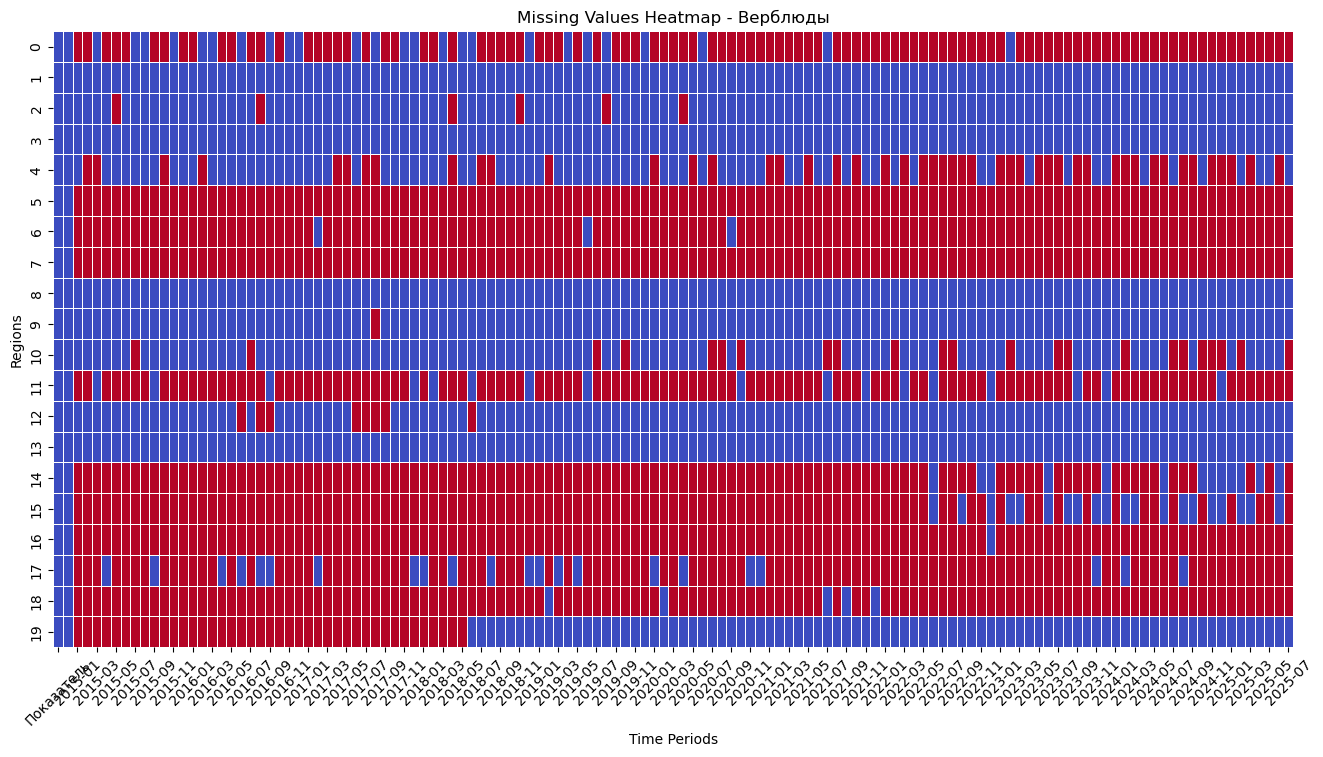

In [74]:
# # Replace "нетнетнет" with NaN for easier handling
# totals.replace("нетнетнет", np.nan, inplace=True)

# # Convert all values to numeric, keeping NaNs
# totals_numeric = totals.set_index("Регион").apply(pd.to_numeric, errors="coerce")
totals_camel = totals[totals['Показатель'] == 'Верблюды']
# Create heatmap: 1 for missing values, 0 for present values
missing_heatmap = totals_camel.isna()

# Plot heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(missing_heatmap, cmap="coolwarm", cbar=False, linewidths=0.5)
plt.title('Missing Values Heatmap - Верблюды')
plt.xlabel("Time Periods")
plt.ylabel("Regions")
plt.xticks(rotation=45)
plt.show()

In [75]:
# сохранение обработанного датасета по 8 показателям
totals.to_excel("output data/Просуммированные по категориям v2.xlsx", index=False)

### Добавление данных по дополнительным потенциальным регрессорам (температура, осадки, поголовье)

In [25]:
# загружаем данные по дополнительным регрессорам
x_vars = pd.read_excel("output data/доп регрессоры обработанные.xlsx")
x_vars.head(5)

,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
0,Температура,АКМОЛИНСКАЯ ОБЛАСТЬ,-12.490323,-10.192857,-5.870968,4.490000,14.574194,20.763333,19.180645,16.529032,11.496667,2.925806,-8.270000,-6.145161,-17.790323,-7.431034,-2.167742,8.633333,13.106452,17.490000,19.106452,20.048387,13.530000,0.370968,-9.976667,-12.954839,-12.264516,-12.989286,-5.403226,5.603333,13.835484,19.546667,18.829032,19.441935,11.596667,2.796774,-1.766667,-10.670968,-18.625806,-14.717857,-8.196774,3.550000,9.506452,17.113333,20.348387,16.616129,11.983333,5.232258,-4.856667,-13.967742,-12.832258,-14.260714,-2.048387,4.333333,13.312903,16.046667,21.670968,18.267742,10.853333,6.922581,-7.266667,-8.038710,-7.838710,-5.851724,-1.441935,9.550000,17.687097,17.110000,21.548387,19.616129,11.306667,5.303226,-5.140000,-13.048387,-17.587097,-14.053571,-7.406452,5.130000,18.716129,18.466667,21.235484,20.074194,10.353333,4.506452,-5.856667,-8.493548,-11.683871,-9.200000,-8.535484,8.873333,15.338710,18.736667,20.583871,17.632258,13.930000,4.709677,-7.810000,-14.154839,-11.600000,-12.278571,-1.867742,5.656667,14.829032,19.796667,24.054839,18.738710,12.866667,6.474194,0.103333,-11.683871,-12.638710,-13.644828,-4.809677,8.026667,10.696774,21.043333,20.270968,17.338710,11.300000,3.832258,-4.343333,-7.638710
1,Температура,АКТЮБИНСКАЯ ОБЛАСТЬ,-13.483871,-11.821429,-5.990323,6.356667,15.609677,25.126667,23.167742,20.732258,16.576667,4.187097,-2.920000,-3.845161,-12.474194,-3.806897,-1.054839,9.783333,16.167742,19.766667,22.332258,24.861290,13.863333,3.980645,-4.056667,-10.980645,-10.119355,-12.132143,-5.500000,5.953333,14.645161,19.843333,23.587097,23.758065,15.550000,5.164516,1.133333,-10.583871,-15.477419,-11.739286,-7.812903,6.746667,16.445161,18.810000,25.893548,20.570968,15.266667,6.838710,-4.470000,-9.922581,-12.296774,-11.685714,-0.583871,8.230000,17.806452,22.266667,24.580645,19.545161,10.923333,8.012903,-4.690000,-7.016129,-5.767742,-5.320690,0.874194,8.100000,17.722581,21.006667,25.261290,20.774194,13.356667,6.409677,-4.913333,-13.645161,-11.145161,-10.978571,-6.683871,7.923333,20.609677,24.920000,23.458065,24.222581,12.753333,5.693548,-3.143333,-6.532258,-9.961290,-5.875000,-6.783871,10.880000,13.245161,20.303333,22.854839,23.264516,15.700000,6.512903,-2.326667,-11.690323,-15.625806,-10.800000,1.522581,10.190000,17.077419,21.763333,24.461290,22.083871,14.703333,7.032258,2.976667,-7.170968,-11.206452,-11.568966,-4.800000,13.513333,13.083871,22.893333,22.912903,20.206452,14.083333,6.667742,-1.520000,-6.419355
2,Температура,АЛМАТИНСКАЯ ОБЛАСТЬ,-5.432258,-1.100000,2.909677,12.126667,17.180645,20.980000,25.564516,22.100000,14.036667,9.780645,2.073333,-3.306452,-2.987097,-3.148276,7.732258,12.073333,15.458065,21.406667,22.287097,21.003226,18.433333,5.293548,-2.963333,-2.283871,-5.312903,-4.157143,2.177419,10.100000,17.093548,20.503333,24.967742,21.006452,16.506667,8.367742,2.550000,-4.222581,-13.251613,-4.892857,6.809677,10.826667,14.519355,20.166667,23.100000,22.412903,14.736667,8.312903,-2.760000,-5.429032,-4.593548,-3.853571,6.267742,11.760000,15.341935,2

In [26]:
# проверка регрессоров
x_vars['Показатель'].unique()

array(['Температура', 'Поголовье: КРС', 'Поголовье: лошади',
       'Поголовье: овцы и козы', 'Поголовье: свиньи',
       'Поголовье: верблюды', 'Осадки'], dtype=object)

In [27]:
# объединение двух датасетов
df_combined = pd.concat([totals, x_vars], ignore_index=True)
df_combined.sample(10)

,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
329,Поголовье: верблюды,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29400.000000,28012.000000,27508.000000,27533.000000,27211.000000,26714.000000,28025.000000,27785.000000,28139.000000,30099.000000,31808.000000,32167.000000,32002.000000,30113.000000,29581.000000,29365.000000,29041.000000,28721.000000,30353.00000,30353.00000,29796.000000,30304.000000,32380.00,34442.000000,34923.00,34673.000000,34936.000000,34390.000000,34125.000000,33717.00,33059.000000,34275.000000,34116.000000,34509.000000,36603.00,38870.000000,39512.000000,39819.000000,38524.000000,37883.000000,37605.000000,37277.000000,36660.000000,34992.000000,34837.0,35217.000000,37277.000000,39542.00000,40172.000000,40415.000000,39478.000000,38881.00,38543.000000,38386.00,37756.000000,6696.00,6659.000000,6521.000000,6640.000000,6879.000000,7077.000000,6933.000000,6947.00000,6947.000000,7658.000000,7520.000000,7538.000000,38084.00000,37821.000000,37962.000000,39714.000000,42343.000000,43098.000000,1889.000000,2309.00000,2298.00,2293.000000,2293.000000,2264.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Верблюды,ЖАМБЫЛСКАЯ ОБЛАСТЬ,68.460000,36.100000,64.290000,22.05,6.700000,16.950000,17.380000,9.610000,49.690000,27.480000,45.96,16.350000,64.530000,38.070000,52.330000,22.130000,8.030000,18.76,18.100000,9.690000,52.70,27.510000,44.080000,12.960000,55.490000,40.950000,39.590000,23.120000,8.500000,17.270000,16.150000,9.440000,47.060000,25.460000,49.940000,14.210000,57.300000,34.650000,41.430000,22.40,8.210000,17.510000,16.500000,9.280000,49.190000,27.050000,47.270000,13.650000,60.220000,35.190000,42.800000,22.220000,8.600000,18.540000,17.250000,9.580000,49.370000,28.040000,47.790000,14.29000,61.70000,35.800000,43.200000,25.10,8.600000,18.60,17.100000,9.600000,51.040000,28.690000,47.80,14.300000,62.900000,36.600000,44.100000,22.80,8.700000,19.000000,17.500000,9.800000,53.000000,27.100000,48.400000,14.280000,63.700000,36.6,45.000000,22.800000,8.70000,19.200000,17.500000,9.800000,53.10,28.600000,50.84,12.800000,108.21,31.590000,57.560000,16.680000,14.410000,16.020000,13.500000,10.73000,95.970000,22.630000,31.350000,5.810000,109.80000,32.300000,59.000000,17.100000,14.400000,23.740000,14.300000,14.20000,98.50,25.900000,33.600000,5.80000,109.80,36.40,60.40,18.2,15.60,19.7,14.2
290,Поголовье: верблюды,ОБЛАСТЬ ҰЛЫТАУ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,691.000000,700.000000,722.000000,722.00,722.000000,722.00,722.000000,13.00,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.00000,13.000000,13.000000,13.000000,13.

In [28]:
# загружаем данные по дополнительным регрессорам (индексы цен на говядину и баранину)
x_vars2 = pd.read_excel("output data/индекс цен говядина и баранина обработанные.xlsx")
x_vars2.head(5)

,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
0,Цена: Говядина,РЕСПУБЛИКА КАЗАХСТАН,100.1,99.7997,99.7997,99.300701,98.704897,98.704897,98.803602,99.198817,99.298015,100.986082,101.793970,102.099352,101.895154,101.997049,101.793055,102.505606,102.915628,103.224375,103.121151,103.946120,105.401366,105.717570,106.457593,106.883423,108.486675,112.609168,113.847869,114.758652,115.906239,116.485770,117.534142,118.827017,120.371768,120.973627,122.062390,123.283014,123.406297,124.146735,125.388202,126.391308,127.023264,127.531357,127.913951,128.425607,129.067735,129.713074,130.491352,131.404792,131.667601,132.194272,132.194272,133.516214,136.186539,139.318829,141.269293,145.507371,148.708534,151.236579,151.690288,152.752120,153.515881,154.744008,157.374656,160.522149,162.287893,164.235348,164.563818,165.222074,166.709072,167.375909,167.878036,168.381671,168.381671,169.560342,171.255946,172.283481,172.800332,173.664333,177.484949,178.727343,181.586981,182.131742,182.678137,182.495459,182.677954,182.860632,186.700706,188.567713,189.887687,191.216900,192.746636,193.903115,197.393372,199.367305,200.364142,201.165598,202.372592,203.586827,207.862151,209.525048,211.620299,213.948122,214.803914,216.092738,218.037572,218.473648,218.692121,219.348198,220.006242,220.226248,221.107153,221.991582,222.213574,222.658001,222.658001,223.103317,223.326420,223.773073,223.996846,224.892833
1,Цена: Говядина,АКМОЛИНСКАЯ ОБЛАСТЬ,100.0,100.0000,100.0000,99.800000,99.800000,99.800000,99.800000,99.800000,99.800000,99.700200,99.700200,99.700200,99.700200,99.700200,99.700200,99.700200,99.700200,99.700200,99.700200,104.685210,104.685210,104.789895,107.724012,107.724012,107.724012,117.742345,117.742345,117.860088,117.860088,122.928072,122.928072,122.928072,122.928072,122.928072,122.928072,126.738842,126.738842,126.738842,129.780574,132.246405,135.684811,135.820496,138.536906,138.536906,138.536906,139.922275,139.922275,139.922275,140.621887,140.621887,140.621887,140.621887,143.434324,150.749475,151.050974,152.410433,152.410433,153.934537,154.088471,154.088471,154.088471,159.481568,160.916902,169.445498,169.614943,171.650323,171.650323,171.650323,171.821973,171.821973,171.821973,171.821973,171.650151,171.650151,178.687807,184.763193,184.763193,184.763193,191.414668,191.414668,191.414668,191.414668,191.414668,191.606082,191.606082,191.606082,195.438204,195.438204,209.118878,209.327997,209.746653,209.746653,209.956400,210.166356,210.166356,216.051014,216.051014,216.267065,216.483332,220.380032,225.008013,225.233021,225.233021,236.044206,235.100029,235.570229,235.334659,235.569993,235.569993,235.569993,236.512273,236.512273,242.898105,242.898105,246.298678,251.224652,253.485674,253.485674,253.485674,253.485674
2,Цена: Говядина,АКТЮБИНСКАЯ ОБЛАСТЬ,100.0,100.0000,100.0000,100.000000,100.000000,103.200000,103.200000,103.200000,103.200000,103.922400,104.026322,104.026322,104.026322,104.026322,104.026322,104.026322,104.962559,104.962559,104.962559,104.962559,105.277447,105.277447,106.751331,106.751331,111.234887,116.574162,119.371942,119.371942,120.446289,1

In [29]:
x_vars2['Показатель'].unique()

array(['Цена: Говядина', 'Цена: Баранина'], dtype=object)

In [30]:
# объедтинение датасетов
df_combined = pd.concat([df_combined, x_vars2], ignore_index=True)
df_combined.sample(10)

,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
357,Цена: Баранина,АКТЮБИНСКАЯ ОБЛАСТЬ,100.000000,100.000000,100.000000,100.000000,100.000000,96.900000,96.900000,96.900000,96.900000,98.838000,98.936838,98.936838,100.124080,100.224204,100.424653,100.424653,100.725927,100.725927,100.725927,100.725927,100.725927,100.725927,103.445527,103.445527,106.755783,106.969295,109.322619,109.541265,109.869888,109.869888,112.506766,112.506766,112.506766,113.406820,113.406820,115.561549,117.063850,117.063850,121.746404,121.746404,129.903413,1.299034e+02,1.299034e+02,129.903413,129.903413,130.163219,130.423546,130.423546,130.423546,1.304235e+02,1.308148e+02,1.308148e+02,1.326462e+02,1.343706e+02,1.382674e+02,1.382674e+02,1.382674e+02,138.543908,138.959539,1.389595e+02,1.409050e+02,1.418913e+02,1.431683e+02,1.431683e+02,1.431683e+02,1.599190e+02,1.599190e+02,1.618381e+02,1.626472e+02,1.626472e+02,1.639484e+02,1.647682e+02,1.659215e+02,1.728902e+02,1.737547e+02,1.746235e+02,1.775921e+02,1.820319e+02,1.904053e+02,1.911670e+02,1.932698e+02,1.938496e+02,1.954004e+02,1.961820e+02,1.961820e+02,1.967705e+02,2.064123e+02,2.105406e+02,2.118038e+02,2.134982e+02,2.158467e+02,2.158467e+02,2.171418e+02,2.195303e+02,2.210671e+02,2.210671e+02,223.056661,223.056661,227.517794,229.792972,233.010073,235.806194,238.635868,239.113140,239.113140,236.243783,236.243783,242.858608,242.858608,242.858608,242.858608,252.330094,252.330094,264.189609,2.641896e+02,2.655106e+02,2.718828e+02,2.732422e+02,2.746084e+02,2.746084e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
275,Поголовье: верблюды,АТЫРАУСКАЯ ОБЛАСТЬ,28333.000000,27543.000000,29376.000000,30933.000000,31947.000000,31691.000000,31580.000000,31330.000000,31196.000000,30898.000000,30380.000000,29108.000000,28412.000000,28061.000000,29916.000000,31498.000000,32652.000000,32002.000000,31987.000000,31838.000000,31658.000000,31426.000000,31023.000000,29651.000000,29218.000000,28723.000000,30246.000000,31671.000000,32855.000000,32370.000000,32273.000000,32125.000000,31988.000000,31716.000000,31257.000000,30716.000000,30135.000000,29856.000000,31487.000000,32808.000000,33646.000000,3.359100e+04,3.343100e+04,33340.000000,32968.000000,32660.000000,32371.000000,31901.000000,31405.000000,3.108500e+04,3.232700e+04,3.336000e+04,3.455600e+04,3.434900e+04,3.427400e+04,3.413500e+04,3.383000e+04,33427.000000,33106.000000,3.244800e+04,3.244800e+04,3.193500e+04,3.168100e+04,3.302600e+04,3.407300e+04,3.502100e+04,3.502400e+04,3.489700e+04,3.472600e+04,3.447300e+04,3.402900e+04,3.355400e+04,3.293600e+04,3.243100e+04,3.218400e+04,3.351800e+04,3.493700e+04,3.608700e+04,3.595800e+04,3.586200e+04,3.615000e+04,3.573700e+04,3.521400e+04,3.454200e+04,3.435600e+04,3.392800e+04,3.365400e+04,3.515600e+04,3.687200e+04,3.825000e+04,3.812200e+04,3.797700e+04,3.780100e+04,3.750200e+04,3.698400e+04,3.633600e+04,1564.000000,1541.000000,1488.000000,1510.000000,1602.000000,1644.000000,1608.000000,1600.000000,1592.000000,1666.000000,1653.000000,1618.000000,35415.000000,36001.000000,35818.000000,36081

In [31]:
df_combined['Показатель'].unique()

array(['Верблюды', 'КРС', 'Лошади', 'Молоко', 'Овцы и козы', 'Птица',
       'Свиньи', 'Яйца', 'Температура', 'Поголовье: КРС',
       'Поголовье: лошади', 'Поголовье: овцы и козы', 'Поголовье: свиньи',
       'Поголовье: верблюды', 'Осадки', 'Цена: Говядина',
       'Цена: Баранина'], dtype=object)

In [32]:
# загружаем данные по дополнительным регрессорам (индексы цен на молоко и яйца)
x_vars3 = pd.read_excel("output data/индекс цен молоко и яйца обработанные.xlsx")
x_vars3.head(5)

,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
0,Цена: Молоко,РЕСПУБЛИКА КАЗАХСТАН,100.5,100.6005,99.192093,96.414714,94.197176,91.653852,88.995890,88.461915,88.550377,89.612982,92.659823,94.698339,95.834719,96.313893,97.854915,98.442045,97.851392,97.068581,96.486170,96.968600,98.617067,100.392174,102.600802,104.345015,105.492811,108.235624,108.452095,108.343643,108.451986,107.909726,107.370178,106.833327,107.260660,109.298613,111.703182,112.708511,114.399139,115.314332,116.698104,116.231311,115.650155,114.609303,113.348601,113.688647,114.029713,116.196277,117.939221,119.354492,120.906100,122.115161,122.115161,122.359392,121.502876,120.652356,119.928442,120.528084,121.612837,125.990899,128.384726,129.668573,131.483933,133.324708,134.257981,134.123723,133.453105,134.921089,135.595694,136.138077,137.635596,139.424859,141.934506,144.347393,146.945646,149.002885,149.449893,149.748793,149.599044,149.150247,149.001097,149.150098,150.939899,153.053058,156.879384,160.644490,162.893512,166.314276,169.141619,173.539301,176.489469,178.607343,178.785950,179.858666,182.016970,186.567394,194.776359,198.477110,205.026855,206.667070,208.733740,210.403610,211.245225,208.921527,209.966135,209.126270,209.544523,211.011335,211.644369,213.337523,214.404211,215.476232,214.183375,214.183375,214.183375,213.326641,213.753295,214.608308,215.895958,218.486709,220.453089,222.878073
1,Цена: Молоко,АКМОЛИНСКАЯ ОБЛАСТЬ,100.7,100.7000,100.297200,100.196903,96.289224,95.133753,94.372683,95.222037,94.841149,94.651467,95.314027,98.078134,100.333931,100.534599,102.846894,103.155435,102.123881,101.102642,101.001539,100.900538,102.212245,103.029943,105.811751,107.610551,107.825772,108.904030,109.121838,107.921498,110.295770,110.295770,107.207489,109.030016,110.665466,112.436114,113.785347,115.492127,115.607620,115.954442,126.158433,125.275324,125.776426,125.524873,126.026972,126.026972,126.026972,126.531080,126.657611,131.343943,132.657382,132.657382,131.596123,138.965506,134.796541,136.818489,135.313486,135.990053,136.398023,137.216411,139.274658,139.692482,141.089406,142.641390,142.641390,145.779500,147.237295,147.237295,151.507177,151.961699,154.241124,154.241124,154.703847,155.632070,156.254599,158.598418,158.598418,158.598418,158.598418,158.598418,158.598418,158.439819,160.182657,159.862292,161.460915,162.106759,162.593079,163.568637,163.568637,174.364167,175.235988,177.514056,177.514056,178.756654,179.650438,181.446942,199.954530,200.954303,205.375298,205.375298,205.991423,208.875303,209.293054,208.665175,208.665175,208.456510,208.456510,208.456510,208.456510,208.456510,208.456510,208.456510,208.456510,208.039597,207.831557,207.415894,205.549151,205.754700,210.487058,210.908032,211.962572,212.386498
2,Цена: Молоко,АКТЮБИНСКАЯ ОБЛАСТЬ,100.0,99.5000,99.997500,101.997450,101.997450,99.651509,99.751160,99.751160,99.052902,99.647219,99.647219,99.647219,99.647219,100.942633,100.034150,100.034150,96.432920,96.143621,96.239765,96.624724,97.494347,99.639222,97.048603,97.242700,100.646194,107.892720,107.137471,107.137471,107.137471,105.423272,108.480546,

In [33]:
x_vars3['Показатель'].unique()

array(['Цена: Молоко', 'Цена: Яйца'], dtype=object)

In [34]:
# объединение датасетов
df_combined = pd.concat([df_combined, x_vars3], ignore_index=True)
df_combined.sample(10)

,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
130,Свиньи,ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,512.910000,561.700000,624.130000,564.50,492.390000,1162.33,664.940000,558.150000,473.770000,547.370000,1058.620000,1022.840000,506.450000,625.980000,680.680000,619.19,581.640000,1056.620000,819.390000,632.920000,525.500000,552.240000,994.140000,896.300000,492.690000,705.46,721.240000,639.84,639.960000,1098.11,597.810000,699.170000,631.120000,593.490000,937.31,786.720000,651.160000,659.790000,699.290000,768.94,700.550000,848.24,538.090000,650.820000,654.600000,585.500000,1008.49,756.560000,620.580000,643.78,715.780000,737.210000,673.910000,948.730000,448.600000,736.540000,686.53,540.170000,954.300000,828.180000,605.360000,603.090000,747.890000,716.810000,676.83,935.63,503.140000,639.01000,678.870000,549.880000,956.430000,850.000000,636.300000,594.080000,753.600000,821.49,704.940000,900.520000,540.640000,679.840000,693.820000,594.900000,1035.100000,835.400000,691.900000,629.000000,741.300000,780.980000,722.69,929.920000,566.850000,678.360000,465.94,630.430000,552.760000,717.150000,452.310000,400.090000,526.190000,463.600000,425.170000,587.590000,350.960000,306.870000,291.66,284.810000,279.530000,494.800000,325.400000,324.950000,426.380000,407.340000,371.600000,614.910000,369.740000,463.170000,399.19,304.730000,310.400000,513.21000,347.69,288.64,272.95,274.81,287.1,368.67,268.94
269,Поголовье: свиньи,ОБЛАСТЬ ҰЛЫТАУ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1471.000000,1498.000000,793.000000,912.00,848.000000,975.000000,1023.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,235.000000,216.000000,327.000000,357.000000,394.000000,411.000000,411.000000,378.000000,427.00,463.000000,517.000000,517.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
212,Поголовье: лошади,АТЫРАУСКАЯ ОБЛАСТЬ,53414.000000,51172.000000,52949.000000,58326.00,60892.000000,63769.00,62729.000000,61843.000000,60485.000000,59255.000000,57815.000000,59107.000000,57774.000000,56583.000000,58806.000000,64584.00,67678.000000,67572.000000,66876.000000,66084.000000,64618.000000,63710.000000,62106.000000,64138.000000,63017.000000,61631.00,63608.000000,70059.00,73400.000000,76906.00,75873.000000,74979.000000,73553.000000,72511.000000,70659.00,72822.000000,71181.000000,69935.000000,72143.000000,79365.00,83303.000000,85157.00,84048.000000,83034.000000,81671.000000,80451.000000,78029.00,79332.000000,77623.000000,76480.00,78407.000000,85177.000000,89619.000000,90725.000000,89938.000000,88965.000000,87056.00,85938.000000,83236.000000,83817.000000,83817.000000,82182.000000,80519.000000,82728.000000,89379.00,93774.00,96319.000000,95546.00000,94632.000000,92649.000000,91217.000000,88479.000000,91668.000000,89895.000000,88614.00

In [35]:
# сохранение обработанного датасета по 8 показателям (с дополнительными регрессорами)
df_combined.to_excel("output data/Просуммированные по категориям с доп регрессорами.xlsx", index=False)